# 03 — Análisis descriptivo y exploratorio

## Actividad física de ocio y síntomas depresivos en adultos

Notebook final de presentación con **7 gráficos seleccionados**. El enfoque es descriptivo y exploratorio: se muestran patrones observados en la muestra analítica NHANES 2021–2023, sin pruebas de significación ni inferencia poblacional formal.


## 1. Librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Carga y validación de los datos


In [2]:
from pathlib import Path

# Ruta prevista cuando el notebook se encuentra dentro de la carpeta notebooks/.
rutas_candidatas = [
    Path("../data/processed/nhanes_actividad_depresion_final.csv"),
    Path("data/processed/nhanes_actividad_depresion_final.csv"),
    Path("nhanes_actividad_depresion_final.csv")
]

ruta_datos = next(
    (ruta for ruta in rutas_candidatas if ruta.exists()),
    None
)

if ruta_datos is None:
    raise FileNotFoundError(
        "No se encontró nhanes_actividad_depresion_final.csv. "
        "Colócalo en data/processed/ o junto al notebook."
    )

df = pd.read_csv(ruta_datos)


assert df.shape[0] == 5155, "La base analítica debe contener 5.155 participantes."
assert df["id"].is_unique, "La columna id contiene duplicados."
assert not df.isna().any().any(), "La base contiene valores nulos."
assert df["phq9"].between(0, 27).all(), "Hay puntuaciones PHQ-9 fuera del rango 0–27."


## 3. Variables y funciones auxiliares


In [3]:
orden_nivel = [
    "Inactivo",
    "Insuficiente",
    "Recomendado",
    "Alto"
]

orden_perfil = [
    "Inactivo",
    "Solo moderada",
    "Solo vigorosa",
    "Moderada + vigorosa"
]

nombres_sintomas = {
    "phq_interes_placer": "Interés / placer",
    "phq_animo_deprimido": "Ánimo deprimido",
    "phq_problemas_sueno": "Problemas de sueño",
    "phq_fatiga_energia": "Fatiga / energía",
    "phq_apetito": "Apetito",
    "phq_autoestima_fracaso": "Autoestima / fracaso",
    "phq_concentracion": "Concentración",
    "phq_alteracion_psicomotora": "Alteración psicomotora",
    "phq_pensamientos_muerte_autolesion": "Muerte / autolesión"
}


def correlacion_spearman(datos, columna_x, columna_y):
    """Calcula rho de Spearman como medida descriptiva de asociación monotónica."""
    return (
        datos[[columna_x, columna_y]]
        .dropna()
        .corr(method="spearman")
        .loc[columna_x, columna_y]
    )


def error_95_media(desviacion, n):
    """Error aproximado usado para barras de IC 95 % en medias."""
    return 1.96 * desviacion / np.sqrt(n)


def error_95_proporcion(porcentaje, n):
    """Error aproximado usado para barras de IC 95 % en porcentajes."""
    proporcion = porcentaje / 100
    return 1.96 * np.sqrt(proporcion * (1 - proporcion) / n) * 100


In [4]:
rho_principal = correlacion_spearman(
    df,
    "actividad_total_ocio_min_semana",
    "phq9"
)

df_principal = df.assign(
    grupo_actividad=np.where(
        df["actividad_total_ocio_min_semana"] == 0,
        "Inactivo",
        "Con actividad"
    ),
    phq10=df["sintomas_depresivos_relevantes"] == "Sí"
)

orden_principal = ["Inactivo", "Con actividad"]

resumen_principal = (
    df_principal
    .groupby("grupo_actividad")
    .agg(
        participantes=("id", "count"),
        phq9_medio=("phq9", "mean"),
        phq9_mediano=("phq9", "median"),
        porcentaje_phq10=("phq10", "mean")
    )
    .reindex(orden_principal)
)

resumen_principal["porcentaje_phq10"] *= 100


# Gráfico 1

## Actividad física de ocio y puntuación media PHQ-9


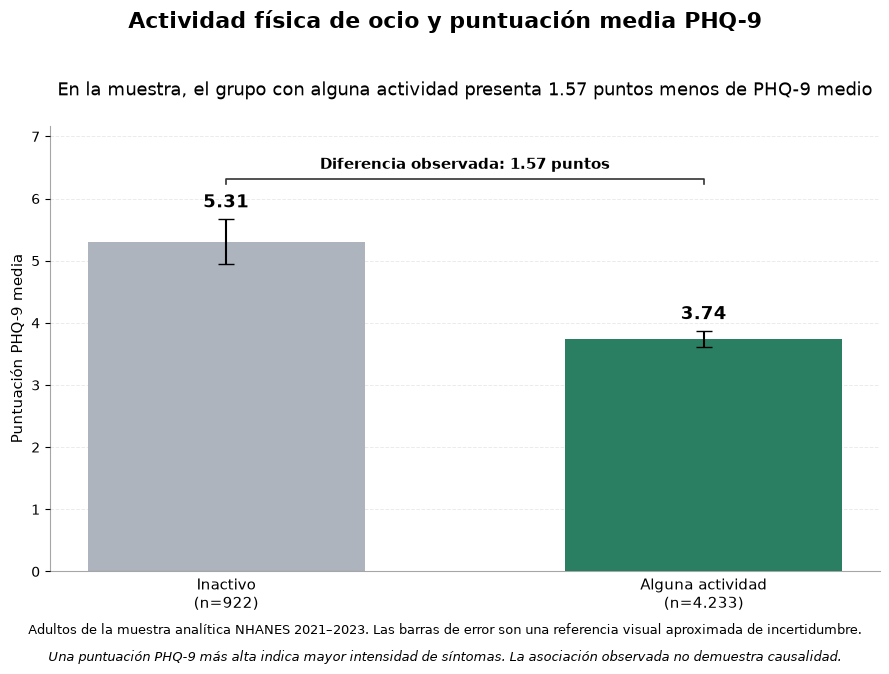

In [5]:
# Creamos los dos grupos que queremos comparar
df_grafico = df.assign(
    grupo_actividad=np.where(
        df["actividad_total_ocio_min_semana"] == 0,
        "Inactivo",
        "Alguna actividad"
    )
)

orden = ["Inactivo", "Alguna actividad"]

resumen_grafico = (
    df_grafico
    .groupby("grupo_actividad")["phq9"]
    .agg(
        n="size",
        media="mean",
        desviacion="std"
    )
    .reindex(orden)
)

resumen_grafico["error_95"] = (
    1.96
    * resumen_grafico["desviacion"]
    / np.sqrt(resumen_grafico["n"])
)

medias = resumen_grafico["media"]
errores = resumen_grafico["error_95"]

diferencia = medias.loc["Inactivo"] - medias.loc["Alguna actividad"]

colores = ["#AEB4BE", "#2A7F62"]

fig, ax = plt.subplots(figsize=(9, 6))

barras = ax.bar(
    orden,
    medias,
    yerr=errores,
    capsize=6,
    color=colores,
    width=0.58,
    edgecolor="none"
)

fig.suptitle(
    "Actividad física de ocio y puntuación media PHQ-9",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

ax.set_title(
    f"En la muestra, el grupo con alguna actividad presenta "
    f"{diferencia:.2f} puntos menos de PHQ-9 medio",
    fontsize=13,
    pad=22
)

for posicion, grupo in enumerate(orden):

    media = resumen_grafico.loc[grupo, "media"]
    error = resumen_grafico.loc[grupo, "error_95"]

    ax.text(
        posicion,
        media + error + 0.12,
        f"{media:.2f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

etiquetas = [
    f"{grupo}\n(n={resumen_grafico.loc[grupo, 'n']:,})"
    .replace(",", ".")
    for grupo in orden
]

ax.set_xticks(range(len(orden)))
ax.set_xticklabels(etiquetas, fontsize=11)

altura = max(medias + errores) + 0.65

ax.plot(
    [0, 0, 1, 1],
    [altura - 0.08, altura, altura, altura - 0.08],
    color="#333333",
    linewidth=1.2
)

ax.text(
    0.5,
    altura + 0.10,
    f"Diferencia observada: {diferencia:.2f} puntos",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Puntuación PHQ-9 media", fontsize=11)

ax.set_ylim(0, altura + 0.85)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", length=0)

fig.text(
    0.5,
    -0.01,
    "Adultos de la muestra analítica NHANES 2021–2023. "
    "Las barras de error son una referencia visual aproximada de incertidumbre.",
    ha="center",
    fontsize=9
)

fig.text(
    0.5,
    -0.055,
    "Una puntuación PHQ-9 más alta indica mayor intensidad de síntomas. "
    "La asociación observada no demuestra causalidad.",
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout()
plt.show()


# Gráfico 2

## Actividad física de ocio y proporción con PHQ-9 ≥10


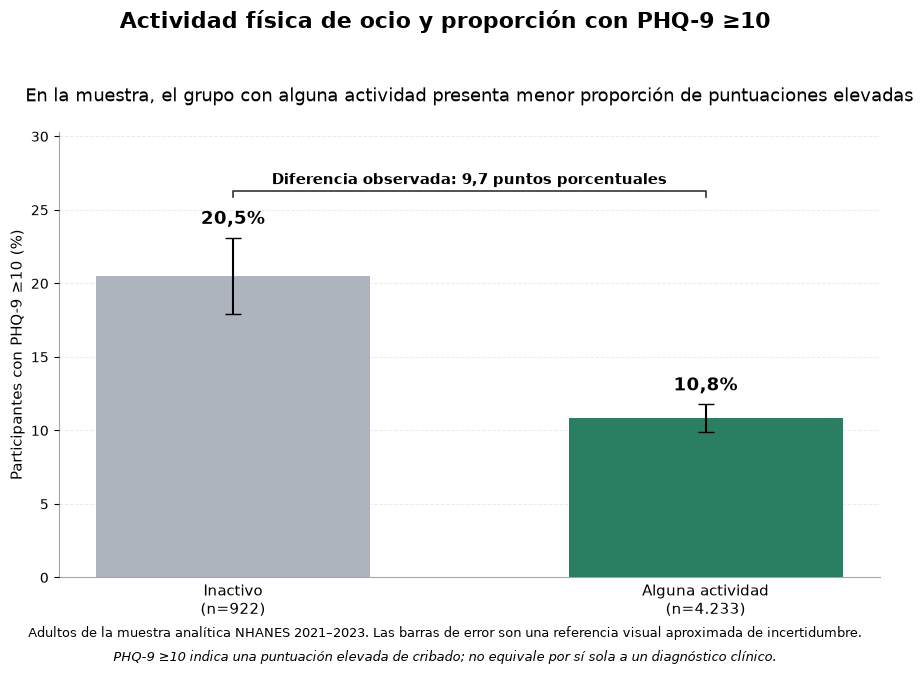

In [6]:
porcentajes = resumen_principal["porcentaje_phq10"]
participantes = resumen_principal["participantes"]

proporciones = porcentajes / 100

error_95 = (
    1.96
    * np.sqrt(
        proporciones
        * (1 - proporciones)
        / participantes
    )
    * 100
)

diferencia_pp = (
    porcentajes.loc["Inactivo"]
    - porcentajes.loc["Con actividad"]
)

colores = ["#AEB4BE", "#2A7F62"]

fig, ax = plt.subplots(figsize=(9, 6))

barras = ax.bar(
    range(len(orden_principal)),
    porcentajes.values,
    yerr=error_95.values,
    capsize=6,
    color=colores,
    width=0.58,
    edgecolor="none"
)

fig.suptitle(
    "Actividad física de ocio y proporción con PHQ-9 ≥10",
    fontsize=16,
    fontweight="bold",
    y=1.04
)

ax.set_title(
    "En la muestra, el grupo con alguna actividad presenta menor proporción "
    "de puntuaciones elevadas",
    fontsize=13,
    pad=22
)

for posicion, grupo in enumerate(orden_principal):

    porcentaje = porcentajes.loc[grupo]
    error = error_95.loc[grupo]

    ax.text(
        posicion,
        porcentaje + error + 0.65,
        f"{porcentaje:.1f}%".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

etiquetas = [
    f"Inactivo\n(n={participantes.loc['Inactivo']:,})",
    f"Alguna actividad\n(n={participantes.loc['Con actividad']:,})"
]

etiquetas = [
    etiqueta.replace(",", ".")
    for etiqueta in etiquetas
]

ax.set_xticks(range(len(orden_principal)))
ax.set_xticklabels(etiquetas, fontsize=11)

altura = max(porcentajes + error_95) + 3.2

ax.plot(
    [0, 0, 1, 1],
    [altura - 0.4, altura, altura, altura - 0.4],
    color="#333333",
    linewidth=1.2
)

ax.text(
    0.5,
    altura + 0.45,
    f"Diferencia observada: {diferencia_pp:.1f} puntos porcentuales"
    .replace(".", ","),
    ha="center",
    fontsize=11,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Participantes con PHQ-9 ≥10 (%)", fontsize=11)

ax.set_ylim(0, altura + 4)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.tick_params(axis="x", length=0)

fig.text(
    0.5,
    -0.005,
    "Adultos de la muestra analítica NHANES 2021–2023. "
    "Las barras de error son una referencia visual aproximada de incertidumbre.",
    ha="center",
    fontsize=9
)

fig.text(
    0.5,
    -0.045,
    "PHQ-9 ≥10 indica una puntuación elevada de cribado; "
    "no equivale por sí sola a un diagnóstico clínico.",
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout()
plt.show()


# Gráfico 3

## Nivel de actividad física y proporción con PHQ-9 ≥10


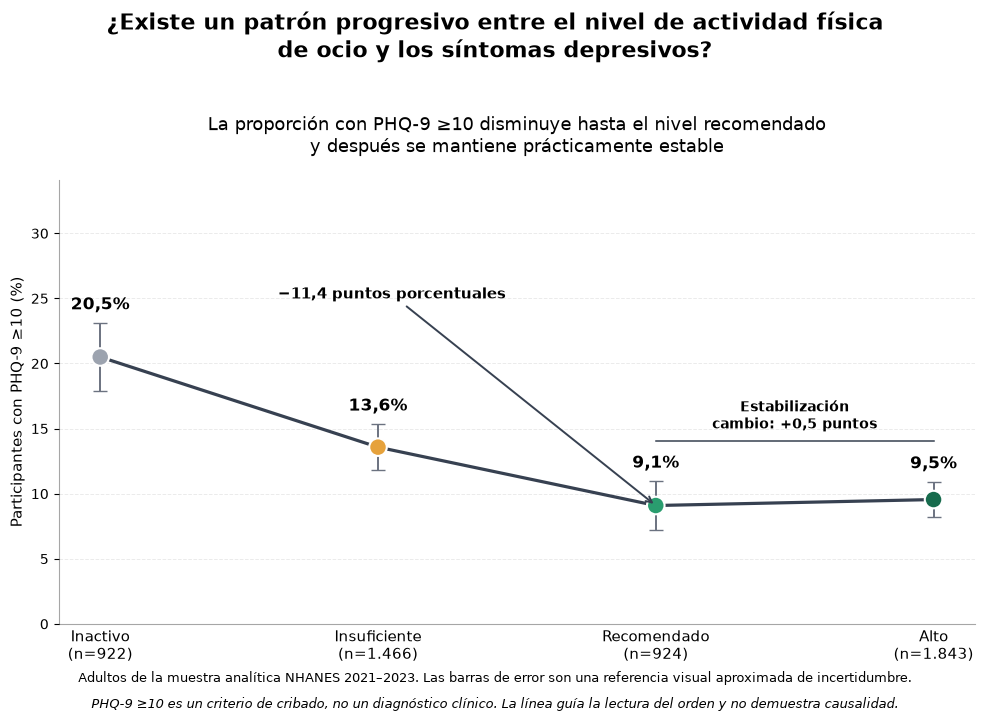

In [7]:
# Orden lógico de los niveles
orden_niveles = [
    "Inactivo",
    "Insuficiente",
    "Recomendado",
    "Alto"
]

# Creamos el resumen directamente desde el DataFrame
resumen_grafico = (
    df
    .groupby("nivel_actividad")
    .agg(
        participantes=("phq9", "size"),
        porcentaje_phq10=(
            "phq9",
            lambda serie: (serie >= 10).mean() * 100
        )
    )
    .reindex(orden_niveles)
)

# Intervalo de confianza aproximado del 95 % para cada proporción
proporciones = resumen_grafico["porcentaje_phq10"] / 100

resumen_grafico["error_95"] = (
    1.96
    * np.sqrt(
        proporciones
        * (1 - proporciones)
        / resumen_grafico["participantes"]
    )
    * 100
)

# Valores que utilizaremos en el gráfico
porcentajes = resumen_grafico["porcentaje_phq10"]
errores = resumen_grafico["error_95"]
posiciones = np.arange(len(orden_niveles))

# Diferencias relevantes para la interpretación
descenso_hasta_recomendado = (
    porcentajes.loc["Inactivo"]
    - porcentajes.loc["Recomendado"]
)

cambio_recomendado_alto = (
    porcentajes.loc["Alto"]
    - porcentajes.loc["Recomendado"]
)

# Colores coherentes con el resto del proyecto
colores = [
    "#9CA3AF",   # Inactivo
    "#E6A23C",   # Insuficiente
    "#2A9D6F",   # Recomendado
    "#176B4D"    # Alto
]

fig, ax = plt.subplots(figsize=(10, 6.5))

# Línea que guía la lectura del patrón ordenado
ax.plot(
    posiciones,
    porcentajes.values,
    color="#374151",
    linewidth=2.3,
    zorder=2
)

# Intervalos de confianza
ax.errorbar(
    posiciones,
    porcentajes.values,
    yerr=errores.values,
    fmt="none",
    ecolor="#6B7280",
    elinewidth=1.4,
    capsize=5,
    zorder=1
)

# Puntos de cada nivel
ax.scatter(
    posiciones,
    porcentajes.values,
    s=160,
    color=colores,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# Pregunta: primer elemento que debe leer el espectador
fig.suptitle(
    "¿Existe un patrón progresivo entre el nivel de actividad física\n"
    "de ocio y los síntomas depresivos?",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

# Respuesta principal
ax.set_title(
    "La proporción con PHQ-9 ≥10 disminuye hasta el nivel recomendado\n"
    "y después se mantiene prácticamente estable",
    fontsize=13,
    pad=20
)

# Porcentajes encima de los puntos
for posicion, porcentaje, error in zip(
    posiciones,
    porcentajes.values,
    errores.values
):
    ax.text(
        posicion,
        porcentaje + error + 0.75,
        f"{porcentaje:.1f}%".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Tamaño de cada grupo en el eje X
etiquetas = [
    (
        f"{nivel}\n"
        f"(n={resumen_grafico.loc[nivel, 'participantes']:,.0f})"
    ).replace(",", ".")
    for nivel in orden_niveles
]

ax.set_xticks(posiciones)
ax.set_xticklabels(
    etiquetas,
    fontsize=10.5
)

# Anotación del descenso principal
ax.annotate(
    (
        f"−{descenso_hasta_recomendado:.1f} "
        "puntos porcentuales"
    ).replace(".", ","),
    xy=(
        2,
        porcentajes.loc["Recomendado"]
    ),
    xytext=(
        1.05,
        porcentajes.loc["Inactivo"] + 4.5
    ),
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1.4,
        "color": "#374151"
    },
    ha="center",
    fontsize=10.5,
    fontweight="bold"
)

# Destacamos la estabilización entre recomendado y alto
altura_estabilizacion = max(
    porcentajes.loc["Recomendado"],
    porcentajes.loc["Alto"]
) + 4.5

ax.plot(
    [2, 3],
    [altura_estabilizacion, altura_estabilizacion],
    color="#374151",
    linewidth=1.1
)

ax.text(
    2.5,
    altura_estabilizacion + 0.6,
    (
        "Estabilización\n"
        f"cambio: {cambio_recomendado_alto:+.1f} puntos"
    ).replace(".", ","),
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

# Ejes claros
ax.set_xlabel("")

ax.set_ylabel(
    "Participantes con PHQ-9 ≥10 (%)",
    fontsize=11
)

# Escala desde cero para no exagerar las diferencias
ax.set_ylim(
    0,
    max(porcentajes + errores) + 11
)

# Cuadrícula suave
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

# Eliminamos ruido visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.tick_params(
    axis="x",
    length=0
)

ax.tick_params(
    axis="y",
    labelsize=10
)

# Contexto
fig.text(
    0.5,
    -0.005,
    "Adultos de la muestra analítica NHANES 2021–2023. "
    "Las barras de error son una referencia visual aproximada de incertidumbre.",
    ha="center",
    fontsize=9
)

# Precauciones
fig.text(
    0.5,
    -0.045,
    "PHQ-9 ≥10 es un criterio de cribado, no un diagnóstico clínico. "
    "La línea guía la lectura del orden y no demuestra causalidad.",
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout()
plt.show()


# Gráfico 4

## Frecuencia, volumen, duración y puntuación PHQ-9


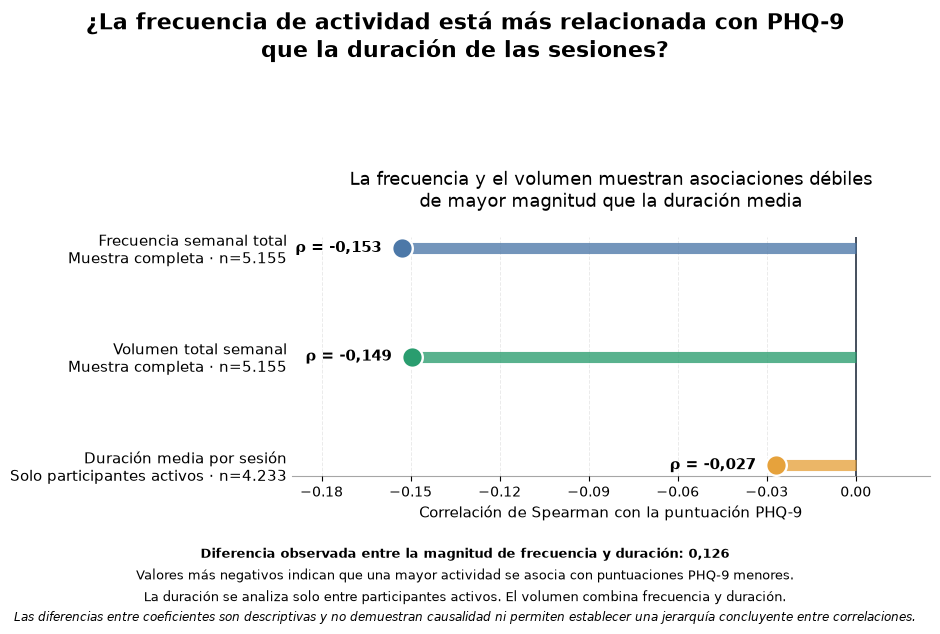

In [8]:
# ---------------------------------------------------------
# 1. Calculamos las tres asociaciones que queremos comparar
# ---------------------------------------------------------

resultados = []

# Frecuencia semanal total: muestra completa
datos_frecuencia = df[
    ["sesiones_totales_semana", "phq9"]
].dropna()

rho_frecuencia = correlacion_spearman(
    datos_frecuencia,
    "sesiones_totales_semana",
    "phq9"
)

resultados.append({
    "variable": "Frecuencia semanal total",
    "rho": rho_frecuencia,
    "n": len(datos_frecuencia),
    "muestra": "Muestra completa"
})


# Volumen total semanal: muestra completa
datos_volumen = df[
    ["actividad_total_ocio_min_semana", "phq9"]
].dropna()

rho_volumen = correlacion_spearman(
    datos_volumen,
    "actividad_total_ocio_min_semana",
    "phq9"
)

resultados.append({
    "variable": "Volumen total semanal",
    "rho": rho_volumen,
    "n": len(datos_volumen),
    "muestra": "Muestra completa"
})


# Duración media: únicamente participantes activos
# En los inactivos, duración = 0 es una convención de cálculo
df_activos = df[
    df["actividad_total_ocio_min_semana"] > 0
]

datos_duracion = df_activos[
    ["duracion_media_sesion_min", "phq9"]
].dropna()

rho_duracion = correlacion_spearman(
    datos_duracion,
    "duracion_media_sesion_min",
    "phq9"
)

resultados.append({
    "variable": "Duración media por sesión",
    "rho": rho_duracion,
    "n": len(datos_duracion),
    "muestra": "Solo participantes activos"
})


tabla_grafico = pd.DataFrame(resultados)

# ---------------------------------------------------------
# 2. Valores para presentar los resultados
# ---------------------------------------------------------

# Diferencia observada entre frecuencia y duración
diferencia_magnitud = (
    abs(rho_frecuencia)
    - abs(rho_duracion)
)

posiciones = np.arange(len(tabla_grafico))

# Colores con significado y utilizables en otros gráficos
colores = [
    "#4C78A8",   # Frecuencia
    "#2A9D6F",   # Volumen
    "#E6A23C"    # Duración
]

# ---------------------------------------------------------
# 3. Gráfico
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6.2))

# Líneas desde cada coeficiente hasta el valor cero
for posicion, fila in tabla_grafico.iterrows():

    ax.hlines(
        y=posicion,
        xmin=fila["rho"],
        xmax=0,
        color=colores[posicion],
        linewidth=8,
        alpha=0.78,
        zorder=2
    )

    # Punto que representa el coeficiente exacto
    ax.scatter(
        fila["rho"],
        posicion,
        s=220,
        color=colores[posicion],
        edgecolor="white",
        linewidth=1.7,
        zorder=3
    )

    # Rho junto al punto
    ax.text(
        fila["rho"] - 0.007,
        posicion,
        f"ρ = {fila['rho']:.3f}".replace(".", ","),
        ha="right",
        va="center",
        fontsize=10.5,
        fontweight="bold"
    )


# Cero = ausencia de asociación monotónica
ax.axvline(
    x=0,
    color="#374151",
    linewidth=1.3,
    zorder=1
)

# Pregunta de investigación
fig.suptitle(
    "¿La frecuencia de actividad está más relacionada con PHQ-9\n"
    "que la duración de las sesiones?",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# Respuesta principal
ax.set_title(
    "La frecuencia y el volumen muestran asociaciones débiles\n"
    "de mayor magnitud que la duración media",
    fontsize=13,
    pad=22
)

# Etiquetas con el tamaño y tipo de muestra
etiquetas = [
    (
        f"{fila['variable']}\n"
        f"{fila['muestra']} · n={fila['n']:,.0f}"
    ).replace(",", ".")
    for _, fila in tabla_grafico.iterrows()
]

ax.set_yticks(posiciones)

ax.set_yticklabels(
    etiquetas,
    fontsize=10.5
)

# Frecuencia aparece en la parte superior
ax.invert_yaxis()

# Eje interpretativo
ax.set_xlabel(
    "Correlación de Spearman con la puntuación PHQ-9",
    fontsize=11
)

ax.set_ylabel("")

# Escala común para comparar las tres correlaciones
ax.set_xlim(-0.19, 0.025)

ax.set_xticks(
    np.arange(-0.18, 0.01, 0.03)
)

# Cuadrícula suave
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

# Eliminamos ruido visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_alpha(0.35)

ax.tick_params(
    axis="y",
    length=0
)

ax.tick_params(
    axis="x",
    labelsize=10
)

# Diferencia principal que queremos destacar
fig.text(
    0.5,
    0.095,
    (
        "Diferencia observada entre la magnitud de frecuencia y duración: "
        f"{diferencia_magnitud:.3f}"
    ).replace(".", ","),
    ha="center",
    fontsize=9.5,
    fontweight="bold"
)

# Ayuda para interpretar el eje
fig.text(
    0.5,
    0.060,
    "Valores más negativos indican que una mayor actividad se asocia "
    "con puntuaciones PHQ-9 menores.",
    ha="center",
    fontsize=9.2
)

# Precauciones metodológicas
fig.text(
    0.5,
    0.025,
    "La duración se analiza solo entre participantes activos. "
    "El volumen combina frecuencia y duración.",
    ha="center",
    fontsize=9
)

fig.text(
    0.5,
    -0.007,
    "Las diferencias entre coeficientes son descriptivas y no demuestran "
    "causalidad ni permiten establecer una jerarquía concluyente entre correlaciones.",
    ha="center",
    fontsize=8.8,
    style="italic"
)

plt.tight_layout(
    rect=[0.03, 0.13, 0.98, 0.86]
)

plt.show()


# Gráfico 5

## Síntomas individuales del PHQ-9 y actividad física de ocio


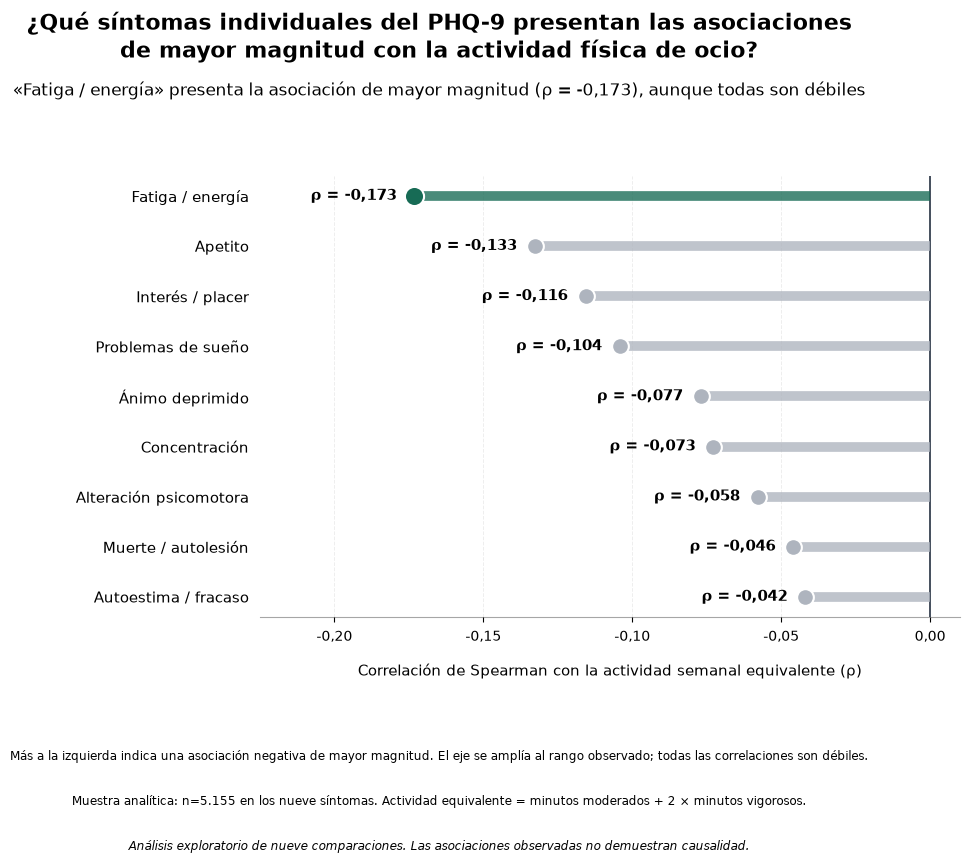

In [9]:
resultados_sintomas = []

for columna, nombre in nombres_sintomas.items():
    rho = correlacion_spearman(
        df,
        "actividad_equivalente_ocio_min_semana",
        columna
    )

    resultados_sintomas.append({
        "sintoma": nombre,
        "rho": rho,
        "magnitud": abs(rho)
    })

tabla_sintomas = (
    pd.DataFrame(resultados_sintomas)
    .sort_values("magnitud", ascending=False)
)

# ---------------------------------------------------------
# GRÁFICO DEFINITIVO
# ASOCIACIÓN ENTRE ACTIVIDAD Y SÍNTOMAS INDIVIDUALES
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ---------------------------------------------------------
# 1. PREPARACIÓN DE LOS DATOS
# ---------------------------------------------------------

# Creamos una copia para no modificar la tabla original
tabla_sintomas_grafico = tabla_sintomas.copy()

# Calculamos la magnitud absoluta de las correlaciones
# para ordenar los síntomas de mayor a menor asociación
tabla_sintomas_grafico["magnitud"] = (
    tabla_sintomas_grafico["rho"].abs()
)

tabla_sintomas_grafico = (
    tabla_sintomas_grafico
    .sort_values(
        "magnitud",
        ascending=False
    )
    .reset_index(drop=True)
)

# Síntoma con la asociación observada de mayor magnitud
sintoma_principal = tabla_sintomas_grafico.loc[
    0,
    "sintoma"
]

rho_principal_sintoma = tabla_sintomas_grafico.loc[
    0,
    "rho"
]

# Posiciones verticales
posiciones = np.arange(
    len(tabla_sintomas_grafico)
)

# Destacamos únicamente el resultado principal
colores = [
    "#176B55" if posicion == 0 else "#AEB4BE"
    for posicion in posiciones
]


# ---------------------------------------------------------
# 2. CREACIÓN DE LA FIGURA
# ---------------------------------------------------------

# Aumentamos la altura para separar correctamente
# el gráfico, el título del eje y las notas inferiores
fig, ax = plt.subplots(
    figsize=(11.2, 9)
)


# ---------------------------------------------------------
# 3. COEFICIENTES
# ---------------------------------------------------------

for posicion, fila in tabla_sintomas_grafico.iterrows():

    color = colores[posicion]

    # Línea desde el coeficiente hasta cero
    ax.hlines(
        y=posicion,
        xmin=fila["rho"],
        xmax=0,
        color=color,
        linewidth=7,
        alpha=0.78,
        zorder=2
    )

    # Punto que representa el coeficiente exacto
    ax.scatter(
        fila["rho"],
        posicion,
        s=190 if posicion == 0 else 145,
        color=color,
        edgecolor="white",
        linewidth=1.5,
        zorder=3
    )

    # Valor exacto de la correlación
    ax.text(
        fila["rho"] - 0.006,
        posicion,
        f"ρ = {fila['rho']:.3f}".replace(".", ","),
        ha="right",
        va="center",
        fontsize=10.5,
        fontweight="bold"
    )

# Línea de referencia:
# cero indica ausencia de asociación monotónica
ax.axvline(
    x=0,
    color="#374151",
    linewidth=1.3,
    zorder=1
)


# ---------------------------------------------------------
# 4. PREGUNTA Y HALLAZGO PRINCIPAL
# ---------------------------------------------------------

fig.suptitle(
    "¿Qué síntomas individuales del PHQ-9 presentan las asociaciones\n"
    "de mayor magnitud con la actividad física de ocio?",
    fontsize=16,
    fontweight="bold",
    y=0.975
)

fig.text(
    0.5,
    0.885,
    (
        f"«{sintoma_principal}» presenta la asociación de mayor magnitud "
        f"(ρ = {rho_principal_sintoma:.3f}), aunque todas son débiles"
    ).replace(".", ","),
    ha="center",
    va="center",
    fontsize=12.5
)


# ---------------------------------------------------------
# 5. ETIQUETAS DE LOS SÍNTOMAS
# ---------------------------------------------------------

ax.set_yticks(posiciones)

ax.set_yticklabels(
    tabla_sintomas_grafico["sintoma"],
    fontsize=10.5
)

# El síntoma con mayor asociación aparece arriba
ax.invert_yaxis()


# ---------------------------------------------------------
# 6. EJE Y ESCALA
# ---------------------------------------------------------

ax.set_xlabel(
    "Correlación de Spearman con la actividad semanal equivalente (ρ)",
    fontsize=11,
    labelpad=14
)

ax.set_ylabel("")

# Dejamos espacio adicional a la izquierda para que
# no se corten los coeficientes escritos junto a los puntos
ax.set_xlim(
    -0.225,
    0.01
)

ax.set_xticks(
    [-0.20, -0.15, -0.10, -0.05, 0]
)

# Formato español de decimales
ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicion:
        f"{valor:.2f}".replace(".", ",")
    )
)

# Cuadrícula suave
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.22
)

ax.set_axisbelow(True)


# ---------------------------------------------------------
# 7. LIMPIEZA VISUAL
# ---------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_alpha(0.35)

ax.tick_params(
    axis="y",
    length=0,
    pad=8
)

ax.tick_params(
    axis="x",
    labelsize=10,
    pad=6
)


# ---------------------------------------------------------
# 8. CONTEXTO Y PRECAUCIONES
# ---------------------------------------------------------

# Línea 1: interpretación del eje
fig.text(
    0.5,
    0.145,
    (
        "Más a la izquierda indica una asociación negativa de mayor magnitud. "
        "El eje se amplía al rango observado; todas las correlaciones son débiles."
    ),
    ha="center",
    va="center",
    fontsize=8.9
)

# Línea 2: muestra y definición de actividad equivalente
fig.text(
    0.5,
    0.095,
    (
        "Muestra analítica: n=5.155 en los nueve síntomas. "
        "Actividad equivalente = minutos moderados + 2 × minutos vigorosos."
    ),
    ha="center",
    va="center",
    fontsize=8.9
)

# Línea 3: naturaleza exploratoria y no causal
fig.text(
    0.5,
    0.045,
    (
        "Análisis exploratorio de nueve comparaciones. "
        "Las asociaciones observadas no demuestran causalidad."
    ),
    ha="center",
    va="center",
    fontsize=8.8,
    style="italic"
)


# ---------------------------------------------------------
# 9. DISTRIBUCIÓN DEFINITIVA DEL ESPACIO
# ---------------------------------------------------------

# Reservamos una zona inferior independiente para:
# - etiquetas del eje X
# - título del eje
# - tres notas metodológicas
fig.subplots_adjust(
    left=0.34,
    right=0.965,
    top=0.79,
    bottom=0.30
)

# No utilizamos tight_layout(), porque podría desplazar
# nuevamente los textos colocados manualmente
plt.show()


# Gráfico 6

## Actividad moderada, actividad vigorosa y puntuación PHQ-9


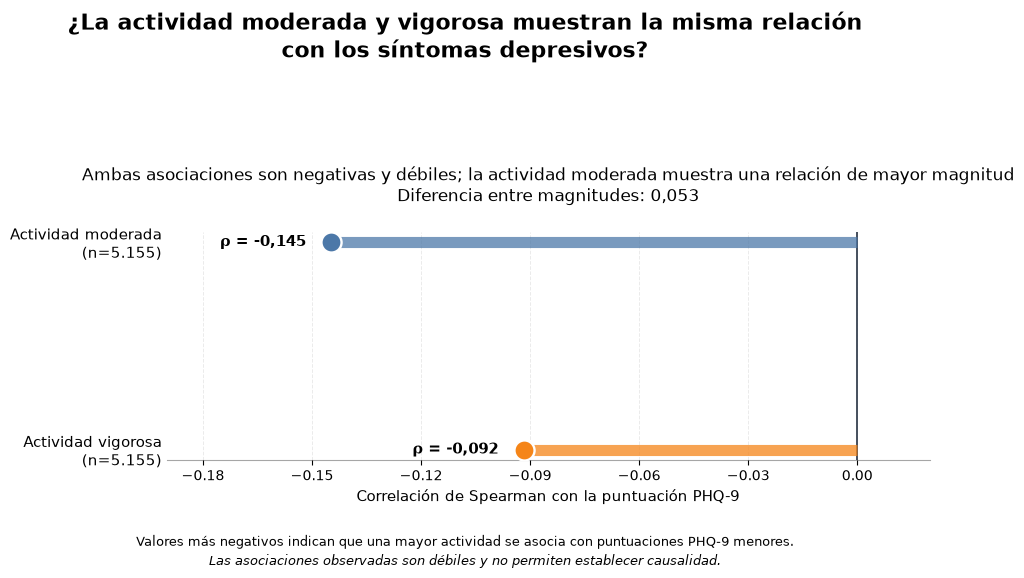

In [10]:
# Variables que queremos comparar
variables_intensidad = {
    "Actividad moderada": "actividad_moderada_ocio_min_semana",
    "Actividad vigorosa": "actividad_vigorosa_ocio_min_semana"
}

# Calculamos la correlación de Spearman para cada intensidad
resultados = []

for nombre, columna in variables_intensidad.items():

    datos_validos = df[
        [columna, "phq9"]
    ].dropna()

    rho = correlacion_spearman(datos_validos, columna, "phq9")

    resultados.append({
        "intensidad": nombre,
        "rho": rho,
        "participantes": len(datos_validos)
    })

tabla_grafico = pd.DataFrame(resultados)

# Extraemos los coeficientes para construir el mensaje principal
rho_moderada = tabla_grafico.loc[
    tabla_grafico["intensidad"] == "Actividad moderada",
    "rho"
].iloc[0]

rho_vigorosa = tabla_grafico.loc[
    tabla_grafico["intensidad"] == "Actividad vigorosa",
    "rho"
].iloc[0]

# Diferencia entre las magnitudes de las dos asociaciones
diferencia_magnitud = abs(
    abs(rho_moderada) - abs(rho_vigorosa)
)

# Determinamos dinámicamente cuál presenta mayor magnitud
if abs(rho_moderada) > abs(rho_vigorosa):

    mensaje_resultado = (
        "Ambas asociaciones son negativas y débiles; "
        "la actividad moderada muestra una relación de mayor magnitud"
    )

elif abs(rho_vigorosa) > abs(rho_moderada):

    mensaje_resultado = (
        "Ambas asociaciones son negativas y débiles; "
        "la actividad vigorosa muestra una relación de mayor magnitud"
    )

else:

    mensaje_resultado = (
        "La actividad moderada y vigorosa muestran asociaciones "
        "de magnitud prácticamente idéntica"
    )



# Posición vertical de cada intensidad
posiciones = np.arange(len(tabla_grafico))

# Colores que podremos mantener en el resto del proyecto
colores = {
    "Actividad moderada": "#4C78A8",
    "Actividad vigorosa": "#F58518"
}

fig, ax = plt.subplots(figsize=(10, 5.8))

# Línea horizontal desde cero hasta cada coeficiente
for posicion, fila in tabla_grafico.iterrows():

    color = colores[fila["intensidad"]]

    ax.hlines(
        y=posicion,
        xmin=fila["rho"],
        xmax=0,
        color=color,
        linewidth=8,
        alpha=0.75,
        zorder=2
    )

    # Punto que representa el coeficiente exacto
    ax.scatter(
        fila["rho"],
        posicion,
        s=210,
        color=color,
        edgecolor="white",
        linewidth=1.7,
        zorder=3
    )

    # Coeficiente junto al punto
    ax.text(
        fila["rho"] - 0.007,
        posicion,
        f"ρ = {fila['rho']:.3f}".replace(".", ","),
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Línea de referencia: ausencia de asociación monotónica
ax.axvline(
    x=0,
    color="#374151",
    linewidth=1.3,
    zorder=1
)

# Pregunta: primer elemento que debe ver el espectador
fig.suptitle(
    "¿La actividad moderada y vigorosa muestran la misma relación\n"
    "con los síntomas depresivos?",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# Respuesta principal
ax.set_title(
    (
        f"{mensaje_resultado}\n"
        f"Diferencia entre magnitudes: {diferencia_magnitud:.3f}"
    ).replace(".", ","),
    fontsize=12.5,
    pad=22
)

# Tamaños de los grupos junto a las categorías
etiquetas = [
    (
        f"{fila['intensidad']}\n"
        f"(n={fila['participantes']:,.0f})"
    ).replace(",", ".")
    for _, fila in tabla_grafico.iterrows()
]

ax.set_yticks(posiciones)
ax.set_yticklabels(
    etiquetas,
    fontsize=11
)

# La primera categoría aparece arriba
ax.invert_yaxis()

# Eje con significado completo
ax.set_xlabel(
    "Correlación de Spearman con la puntuación PHQ-9",
    fontsize=11
)

ax.set_ylabel("")

# Escala común y honesta
ax.set_xlim(-0.19, 0.02)

# Marcas comprensibles en el eje
ax.set_xticks(
    np.arange(-0.18, 0.01, 0.03)
)

# Cuadrícula suave
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

# Eliminamos elementos visuales innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_alpha(0.35)

ax.tick_params(
    axis="y",
    length=0
)

ax.tick_params(
    axis="x",
    labelsize=10
)

# Contexto interpretativo
fig.text(
    0.5,
    0.055,
    "Valores más negativos indican que una mayor actividad se asocia "
    "con puntuaciones PHQ-9 menores.",
    ha="center",
    fontsize=9.5
)

# Precaución metodológica
fig.text(
    0.5,
    0.022,
    "Las asociaciones observadas son débiles y no permiten establecer causalidad.",
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout(
    rect=[0.03, 0.10, 0.98, 0.86]
)

plt.show()


# Gráfico 7

## Número medio de síntomas presentes y frecuentes por nivel de actividad


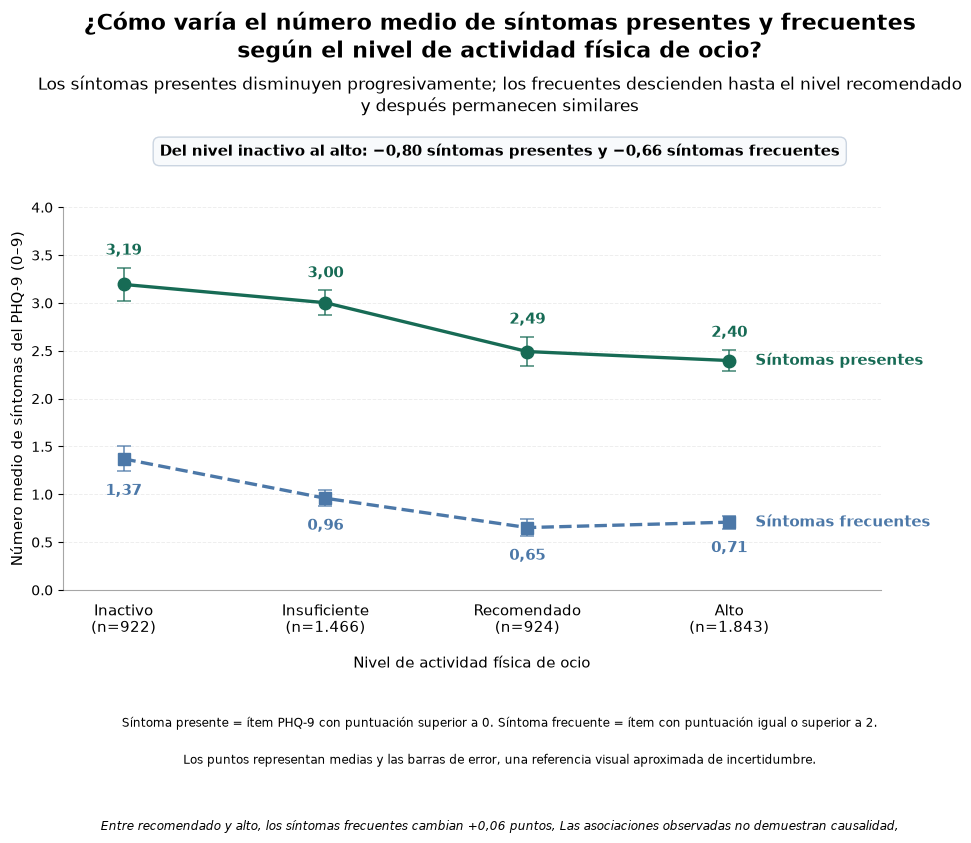

In [11]:
# ---------------------------------------------------------
# GRÁFICO DEFINITIVO
# NÚMERO DE SÍNTOMAS SEGÚN NIVEL DE ACTIVIDAD
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. ORDEN Y RESUMEN DE LOS DATOS
# ---------------------------------------------------------

orden_nivel = [
    "Inactivo",
    "Insuficiente",
    "Recomendado",
    "Alto"
]

resumen_recuento = (
    df
    .groupby("nivel_actividad")
    .agg(
        participantes=("phq9", "size"),

        presentes_media=(
            "numero_sintomas_presentes",
            "mean"
        ),
        presentes_desviacion=(
            "numero_sintomas_presentes",
            "std"
        ),

        frecuentes_media=(
            "numero_sintomas_frecuentes",
            "mean"
        ),
        frecuentes_desviacion=(
            "numero_sintomas_frecuentes",
            "std"
        )
    )
    .reindex(orden_nivel)
)

# Intervalos de confianza aproximados del 95 %
resumen_recuento["presentes_error_95"] = (
    1.96
    * resumen_recuento["presentes_desviacion"]
    / np.sqrt(resumen_recuento["participantes"])
)

resumen_recuento["frecuentes_error_95"] = (
    1.96
    * resumen_recuento["frecuentes_desviacion"]
    / np.sqrt(resumen_recuento["participantes"])
)



# ---------------------------------------------------------
# 3. VALORES PRINCIPALES
# ---------------------------------------------------------

presentes = resumen_recuento["presentes_media"]
frecuentes = resumen_recuento["frecuentes_media"]

errores_presentes = resumen_recuento[
    "presentes_error_95"
]

errores_frecuentes = resumen_recuento[
    "frecuentes_error_95"
]

posiciones_recuento = np.arange(
    len(orden_nivel)
)

# Diferencia entre inactividad y nivel alto
descenso_presentes = (
    presentes.loc["Inactivo"]
    - presentes.loc["Alto"]
)

descenso_frecuentes = (
    frecuentes.loc["Inactivo"]
    - frecuentes.loc["Alto"]
)

# Cambio entre recomendado y alto en síntomas frecuentes
cambio_final_frecuentes = (
    frecuentes.loc["Alto"]
    - frecuentes.loc["Recomendado"]
)


# ---------------------------------------------------------
# 4. CREACIÓN DE LA FIGURA
# ---------------------------------------------------------

color_presentes = "#176B55"
color_frecuentes = "#4C78A8"

fig, ax = plt.subplots(
    figsize=(11.2, 8.6)
)


# ---------------------------------------------------------
# 5. SÍNTOMAS PRESENTES
# ---------------------------------------------------------

ax.plot(
    posiciones_recuento,
    presentes.values,
    color=color_presentes,
    linewidth=2.4,
    marker="o",
    markersize=9,
    label="Síntomas presentes",
    zorder=3
)

ax.errorbar(
    posiciones_recuento,
    presentes.values,
    yerr=errores_presentes.values,
    fmt="none",
    ecolor=color_presentes,
    elinewidth=1.3,
    capsize=5,
    capthick=1.2,
    alpha=0.75,
    zorder=2
)


# ---------------------------------------------------------
# 6. SÍNTOMAS FRECUENTES
# ---------------------------------------------------------

ax.plot(
    posiciones_recuento,
    frecuentes.values,
    color=color_frecuentes,
    linewidth=2.4,
    linestyle="--",
    marker="s",
    markersize=8,
    label="Síntomas frecuentes",
    zorder=3
)

ax.errorbar(
    posiciones_recuento,
    frecuentes.values,
    yerr=errores_frecuentes.values,
    fmt="none",
    ecolor=color_frecuentes,
    elinewidth=1.3,
    capsize=5,
    capthick=1.2,
    alpha=0.75,
    zorder=2
)


# ---------------------------------------------------------
# 7. PREGUNTA, HALLAZGO Y MAGNITUD
# ---------------------------------------------------------

fig.suptitle(
    "¿Cómo varía el número medio de síntomas presentes y frecuentes\n"
    "según el nivel de actividad física de ocio?",
    fontsize=16,
    fontweight="bold",
    y=0.975
)

fig.text(
    0.5,
    0.875,
    (
        "Los síntomas presentes disminuyen progresivamente; "
        "los frecuentes descienden hasta el nivel recomendado\n"
        "y después permanecen similares"
    ),
    ha="center",
    va="center",
    fontsize=12.5
)

fig.text(
    0.5,
    0.810,
    (
        f"Del nivel inactivo al alto: "
        f"−{descenso_presentes:.2f} síntomas presentes y "
        f"−{descenso_frecuentes:.2f} síntomas frecuentes"
    ).replace(".", ","),
    ha="center",
    va="center",
    fontsize=10.5,
    fontweight="bold",
    bbox={
        "facecolor": "#F8FAFC",
        "edgecolor": "#CBD5E1",
        "boxstyle": "round,pad=0.45",
        "alpha": 1
    }
)


# ---------------------------------------------------------
# 8. VALORES SOBRE LOS PUNTOS
# ---------------------------------------------------------

for posicion, nivel in enumerate(orden_nivel):

    valor_presentes = presentes.loc[nivel]
    error_presentes = errores_presentes.loc[nivel]

    valor_frecuentes = frecuentes.loc[nivel]
    error_frecuentes = errores_frecuentes.loc[nivel]

    # Valor de síntomas presentes
    ax.text(
        posicion,
        valor_presentes + error_presentes + 0.10,
        f"{valor_presentes:.2f}".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color=color_presentes
    )

    # Valor de síntomas frecuentes
    ax.text(
        posicion,
        max(
            0.10,
            valor_frecuentes - error_frecuentes - 0.13
        ),
        f"{valor_frecuentes:.2f}".replace(".", ","),
        ha="center",
        va="top",
        fontsize=10.5,
        fontweight="bold",
        color=color_frecuentes
    )


# ---------------------------------------------------------
# 9. ETIQUETAS DIRECTAS DE LAS LÍNEAS
# ---------------------------------------------------------

ax.text(
    posiciones_recuento[-1] + 0.13,
    presentes.iloc[-1],
    "Síntomas presentes",
    color=color_presentes,
    va="center",
    ha="left",
    fontsize=10.5,
    fontweight="bold"
)

ax.text(
    posiciones_recuento[-1] + 0.13,
    frecuentes.iloc[-1],
    "Síntomas frecuentes",
    color=color_frecuentes,
    va="center",
    ha="left",
    fontsize=10.5,
    fontweight="bold"
)


# ---------------------------------------------------------
# 10. ETIQUETAS DEL EJE X
# ---------------------------------------------------------

etiquetas_nivel = []

for nivel in orden_nivel:

    participantes = resumen_recuento.loc[
        nivel,
        "participantes"
    ]

    etiqueta = (
        f"{nivel}\n"
        f"(n={participantes:,.0f})"
    ).replace(",", ".")

    etiquetas_nivel.append(etiqueta)

ax.set_xticks(posiciones_recuento)

ax.set_xticklabels(
    etiquetas_nivel,
    fontsize=10.5,
    linespacing=1.2
)


# ---------------------------------------------------------
# 11. EJES Y ESCALAS
# ---------------------------------------------------------

ax.set_xlabel(
    "Nivel de actividad física de ocio",
    fontsize=11,
    labelpad=14
)

ax.set_ylabel(
    "Número medio de síntomas del PHQ-9 (0–9)",
    fontsize=11
)

# Espacio adicional a la derecha para las etiquetas directas
ax.set_xlim(
    -0.30,
    len(orden_nivel) - 0.25
)

# Escala desde cero y calculada dinámicamente
limite_superior = (
    np.ceil(
        (
            max(presentes + errores_presentes)
            + 0.55
        )
        * 2
    )
    / 2
)

ax.set_ylim(
    0,
    limite_superior
)

ax.set_yticks(
    np.arange(
        0,
        limite_superior + 0.01,
        0.5
    )
)

# Cuadrícula suave
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.22
)

ax.set_axisbelow(True)


# ---------------------------------------------------------
# 12. LIMPIEZA VISUAL
# ---------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

ax.tick_params(
    axis="x",
    length=0,
    pad=8
)

ax.tick_params(
    axis="y",
    labelsize=10
)

# No necesitamos leyenda porque las líneas
# quedan identificadas directamente a la derecha
if ax.get_legend() is not None:
    ax.get_legend().remove()


# ---------------------------------------------------------
# 13. INFORMACIÓN ESTADÍSTICA Y METODOLÓGICA
# ---------------------------------------------------------

fig.text(
    0.5,
    0.145,
    (
        "Síntoma presente = ítem PHQ-9 con puntuación superior a 0. "
        "Síntoma frecuente = ítem con puntuación igual o superior a 2."
    ),
    ha="center",
    va="center",
    fontsize=8.9
)

fig.text(
    0.5,
    0.102,
    (
        "Los puntos representan medias y las barras de error, "
        "una referencia visual aproximada de incertidumbre."
    ),
    ha="center",
    va="center",
    fontsize=8.8
)

fig.text(
    0.5,
    0.025,
    (
        f"Entre recomendado y alto, los síntomas frecuentes cambian "
        f"{cambio_final_frecuentes:+.2f} puntos. "
        "Las asociaciones observadas no demuestran causalidad."
    ).replace(".", ","),
    ha="center",
    va="center",
    fontsize=8.7,
    style="italic"
)


# ---------------------------------------------------------
# 14. DISTRIBUCIÓN DEFINITIVA DEL ESPACIO
# ---------------------------------------------------------

fig.subplots_adjust(
    left=0.11,
    right=0.84,
    top=0.745,
    bottom=0.30
)

# No utilizamos tight_layout(), porque podría volver
# a desplazar los textos colocados manualmente
plt.show()


# Cierre interpretativo

Los siete gráficos apuntan en la misma dirección descriptiva: en esta muestra, mayor actividad física de ocio coincide con menor PHQ-9 medio, menor proporción con PHQ-9 ≥10 y menor número medio de síntomas presentes y frecuentes. La magnitud de las asociaciones es débil y el diseño transversal no permite afirmar causalidad.
